In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 🌾 KrishiMitra AI
## AI-Powered Multilingual Crop Disease Assistant using Gemma 4

### Build with Gemma: Kolkata 2026
**Track:** GenAI for Good

---

### Overview

KrishiMitra AI is an intelligent agricultural assistant that helps farmers identify possible crop diseases using a single image.

Unlike traditional disease classifiers, our system combines **Gemma 4's multimodal vision capabilities** with **context-aware reasoning**.

The workflow consists of:

1. Upload a crop image.
2. Detect the probable disease.
3. Ask follow-up questions.
4. Estimate severity and urgency.
5. Recommend treatment and prevention.
6. Translate recommendations into regional languages.
7. Generate a structured farmer-friendly report.

---

### Gemma Features Used

- ✅ Vision Understanding
- ✅ Multimodal Reasoning
- ✅ Structured JSON Generation
- ✅ Multilingual Response Generation


In [3]:
!pip -q install -U google-genai pillow ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.0/958.0 kB 20.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.47.0, but you have goog

**Load API Key & Initialize Gemma**

In [4]:
import os
from google import genai
from kaggle_secrets import UserSecretsClient

# Load API Key securely from Kaggle Secrets
user_secrets = UserSecretsClient()
GOOGLE_API_KEY = user_secrets.get_secret("GOOGLE_API_KEY")

# Initialize the client
client = genai.Client(api_key=GOOGLE_API_KEY)

print("✅ Gemma client initialized successfully.")

✅ Gemma client initialized successfully.


In [6]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-omni-flash-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
mod

In [9]:
response = client.models.generate_content(
    model="models/gemma-4-31b-it",
    contents="Reply with only one word: Connected"
)

print(response.text)

Connected


## 🌿 Step 1: Upload Crop Image

Upload an image of a crop leaf, fruit, or plant showing signs of disease.

Gemma 4 will analyze the image, identify possible diseases, ask follow-up questions, and provide multilingual recommendations.

In [17]:
import io
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='📤 Upload Crop Image'
)

display(upload_widget)

FileUpload(value=(), accept='image/*', description='📤 Upload Crop Image')

✅ Image Loaded: Screenshot from 2026-07-05 11-19-08.png
📏 Image Size: (548, 444)


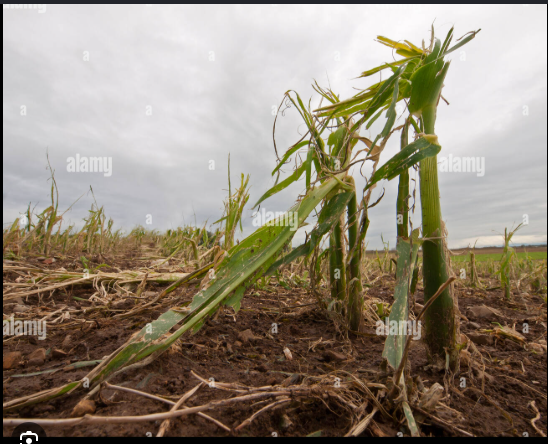

In [19]:
import io
from PIL import Image
from IPython.display import display

# Ensure an image is uploaded
if len(upload_widget.value) == 0:
    raise ValueError("Please upload an image first.")

# Get uploaded file (Kaggle returns a tuple)
uploaded_file = upload_widget.value[0]

# Read image bytes
image_bytes = uploaded_file["content"]

# Convert memoryview to bytes if necessary
if isinstance(image_bytes, memoryview):
    image_bytes = image_bytes.tobytes()

# Load image
image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

print(f"✅ Image Loaded: {uploaded_file['name']}")
print(f"📏 Image Size: {image.size}")

display(image)

In [14]:
print(type(upload_widget.value))
print(upload_widget.value)

<class 'tuple'>
({'name': 'Screenshot from 2026-07-05 11-19-08.png', 'type': 'image/png', 'size': 426752, 'content': <memory at 0x7ab82f72ba00>, 'last_modified': datetime.datetime(2026, 7, 5, 5, 49, 8, 652000, tzinfo=datetime.timezone.utc)},)


In [20]:
MODEL_NAME = "models/gemma-4-31b-it"

In [21]:
import json

vision_prompt = """
You are an expert agricultural scientist.

Analyze the uploaded crop image.

Return ONLY valid JSON.

Schema:

{
  "crop": "",
  "possible_disease": "",
  "confidence": "",
  "visible_symptoms": [],
  "severity": "",
  "reasoning": ""
}

Rules:
- confidence should be percentage.
- severity should be Low, Medium or High.
- reasoning should explain why you predicted the disease.
- Return ONLY JSON.
"""

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[
        image,
        vision_prompt
    ]
)

print(response.text)

```json
{
  "crop": "Maize (Corn)",
  "possible_disease": "None (Physical/Abiotic Damage)",
  "confidence": "95%",
  "visible_symptoms": [
    "Broken stalks",
    "Shredded leaves",
    "Lodging (flattened plants)",
    "Mechanical tearing of foliage"
  ],
  "severity": "High",
  "reasoning": "The damage observed is clearly mechanical rather than pathogenic. The leaves are torn and shredded, and the stalks are snapped or bent over, which is characteristic of severe weather events such as high winds or a hailstorm. There are no visible fungal lesions, bacterial ooze, or viral discoloration that would indicate a biological disease."
}
```


In [22]:
import json

# Remove markdown fences if present
json_text = response.text.strip()

if json_text.startswith("```json"):
    json_text = json_text.replace("```json", "").replace("```", "").strip()

result = json.loads(json_text)

result

{'crop': 'Maize (Corn)',
 'possible_disease': 'None (Physical/Abiotic Damage)',
 'confidence': '95%',
 'visible_symptoms': ['Broken stalks',
  'Shredded leaves',
  'Lodging (flattened plants)',
  'Mechanical tearing of foliage'],
 'severity': 'High',
 'reasoning': 'The damage observed is clearly mechanical rather than pathogenic. The leaves are torn and shredded, and the stalks are snapped or bent over, which is characteristic of severe weather events such as high winds or a hailstorm. There are no visible fungal lesions, bacterial ooze, or viral discoloration that would indicate a biological disease.'}

In [23]:
print("=" * 60)
print("🌾 KRISHIMITRA AI REPORT")
print("=" * 60)

print(f"🌱 Crop              : {result['crop']}")
print(f"🦠 Possible Issue    : {result['possible_disease']}")
print(f"📊 Confidence        : {result['confidence']}")
print(f"🚨 Severity          : {result['severity']}")

print("\n👀 Visible Symptoms")
for symptom in result["visible_symptoms"]:
    print(f"   • {symptom}")

print("\n🧠 AI Reasoning")
print(result["reasoning"])

print("=" * 60)

🌾 KRISHIMITRA AI REPORT
🌱 Crop              : Maize (Corn)
🦠 Possible Issue    : None (Physical/Abiotic Damage)
📊 Confidence        : 95%
🚨 Severity          : High

👀 Visible Symptoms
   • Broken stalks
   • Shredded leaves
   • Lodging (flattened plants)
   • Mechanical tearing of foliage

🧠 AI Reasoning
The damage observed is clearly mechanical rather than pathogenic. The leaves are torn and shredded, and the stalks are snapped or bent over, which is characteristic of severe weather events such as high winds or a hailstorm. There are no visible fungal lesions, bacterial ooze, or viral discoloration that would indicate a biological disease.


In [24]:
followup_prompt = f"""
You are an agricultural expert.

Crop:
{result['crop']}

Possible Issue:
{result['possible_disease']}

Severity:
{result['severity']}

Visible Symptoms:
{', '.join(result['visible_symptoms'])}

Generate exactly 3 important follow-up questions that would help confirm the diagnosis.

Return ONLY JSON.

{{
    "questions": [
        "...",
        "...",
        "..."
    ]
}}
"""

response2 = client.models.generate_content(
    model=MODEL_NAME,
    contents=followup_prompt
)

print(response2.text)

```json
{
    "questions": [
        "Was there a recent high-wind event, thunderstorm, or hail storm in the area immediately preceding the appearance of these symptoms?",
        "Is the damage uniformly distributed across the field, or is it concentrated in specific patterns such as field edges or along equipment paths?",
        "Did these symptoms appear suddenly overnight, or have they developed gradually over a period of several days?"
    ]
}
```


In [25]:
import json

# Clean markdown formatting if present
json_text = response.text.strip()

if json_text.startswith("```json"):
    json_text = json_text.replace("```json", "").replace("```", "").strip()

# Parse JSON
result = json.loads(json_text)

result

{'crop': 'Maize (Corn)',
 'possible_disease': 'None (Physical/Abiotic Damage)',
 'confidence': '95%',
 'visible_symptoms': ['Broken stalks',
  'Shredded leaves',
  'Lodging (flattened plants)',
  'Mechanical tearing of foliage'],
 'severity': 'High',
 'reasoning': 'The damage observed is clearly mechanical rather than pathogenic. The leaves are torn and shredded, and the stalks are snapped or bent over, which is characteristic of severe weather events such as high winds or a hailstorm. There are no visible fungal lesions, bacterial ooze, or viral discoloration that would indicate a biological disease.'}

In [26]:
print("=" * 60)
print("🌾 KRISHIMITRA AI REPORT")
print("=" * 60)

print(f"🌱 Crop              : {result['crop']}")
print(f"🦠 Possible Issue    : {result['possible_disease']}")
print(f"📊 Confidence        : {result['confidence']}")
print(f"🚨 Severity          : {result['severity']}")

print("\n👀 Visible Symptoms")
for symptom in result["visible_symptoms"]:
    print(f"   • {symptom}")

print("\n🧠 AI Reasoning")
print(result["reasoning"])

print("=" * 60)

🌾 KRISHIMITRA AI REPORT
🌱 Crop              : Maize (Corn)
🦠 Possible Issue    : None (Physical/Abiotic Damage)
📊 Confidence        : 95%
🚨 Severity          : High

👀 Visible Symptoms
   • Broken stalks
   • Shredded leaves
   • Lodging (flattened plants)
   • Mechanical tearing of foliage

🧠 AI Reasoning
The damage observed is clearly mechanical rather than pathogenic. The leaves are torn and shredded, and the stalks are snapped or bent over, which is characteristic of severe weather events such as high winds or a hailstorm. There are no visible fungal lesions, bacterial ooze, or viral discoloration that would indicate a biological disease.


In [27]:
followup_prompt = f"""
You are an agricultural expert.

Crop:
{result['crop']}

Possible Issue:
{result['possible_disease']}

Severity:
{result['severity']}

Visible Symptoms:
{', '.join(result['visible_symptoms'])}

Generate exactly 3 important follow-up questions that would help confirm the diagnosis.

Return ONLY JSON.

{{
  "questions": [
    "...",
    "...",
    "..."
  ]
}}
"""

response2 = client.models.generate_content(
    model=MODEL_NAME,
    contents=followup_prompt
)

print(response2.text)

```json
{
  "questions": [
    "Were there any recent extreme weather events, such as high winds, thunderstorms, or hail, in the affected area?",
    "Is the damage distributed uniformly across the field, or is it concentrated in specific zones, such as the field edges or along equipment paths?",
    "Are there any visible tracks from machinery or signs of animal activity, such as footprints or chew marks, near the damaged plants?"
  ]
}
```
